# ⚡ GOLD BOT V2 — Backtester Multi-Dataset XAUUSD
### Safe / Risque / Risque+++ | Spread & Slippage réalistes
---
**Datasets :** 6 Mois · 1 An · 2 Ans · 3 Ans  
**Modifie uniquement la cellule CONFIG** ci-dessous, puis `Run All`.


## 📦 Installation (dans ton venv, une seule fois)
```bash
pip install pandas numpy matplotlib openpyxl jupyterlab
```


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings, os, re
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
print('Imports OK')


Imports OK


## ⚙️ CONFIGURATION — Tout modifier ici
> Seule cellule à toucher. Relance ensuite `Kernel > Restart & Run All`.


In [2]:
# ═══════════════════════════════════════════════════════
# 📂  FICHIERS CSV
# ═══════════════════════════════════════════════════════
DATASETS = {
    "6 Mois" : "XAUUSD-VIP_M5_6Months_Data.csv",
    "1 An"   : "XAUUSD-VIP_M5_1Year_Data.csv",
    "2 Ans"  : "XAUUSD-VIP_M5_2Years_Data.csv",
    "3 Ans"  : "XAUUSD-VIP_M5_3Years_Data.csv",
}
# Mets False pour ignorer un dataset
DATASET_ENABLED = {k: True for k in DATASETS}

# ═══════════════════════════════════════════════════════
# 💸  COUTS TRANSACTIONNELS
# ═══════════════════════════════════════════════════════
SPREAD   = 0.0   # pts — spread broker  (ECN gold: 0.20-0.50)
SLIPPAGE = 0.0   # pts — glissement/leg (news: jusqu a 0.50)

# ═══════════════════════════════════════════════════════
# 📊  TAILLE DE POSITION
# ═══════════════════════════════════════════════════════
LOT_SIZE    = 0.01    # lots — 0.01 = micro-lot
POINT_VALUE = 100.0   # $/lot/pt  (XAUUSD : 1 lot = 100 oz)

# ═══════════════════════════════════════════════════════
# 🛡️  RISK MANAGEMENT
# ═══════════════════════════════════════════════════════
MAX_RISK_PTS       = 22.0   # risque max/trade (pts)
DAILY_MAX_LOSS     = -150.0 # coupe-circuit jour ($)
MAX_TRADES_PER_DAY = 3      # sequences max/jour

# ═══════════════════════════════════════════════════════
# 🕐  SESSION UTC
# ═══════════════════════════════════════════════════════
SESSION_START_H = 5
SESSION_END_H   = 15
SESSION_MID_H   = 12  # apres cette heure : threshold +10

# ═══════════════════════════════════════════════════════
# ⚡  MODES  (sl/tp multipliers, score_min, cooldown)
# ═══════════════════════════════════════════════════════
MODES_CONFIG = {
    "safe": {
        "sl_mult":2.5,"tp1_mult":1.5,"tp2_mult":2.5,"tp3_mult":4.0,
        "score_min":60,"cooldown_bars":60,
        "label":"SAFE","color":"#2ecc71","desc":"SL large, setups premium",
    },
    "risque": {
        "sl_mult":1.8,"tp1_mult":1.2,"tp2_mult":2.0,"tp3_mult":3.2,
        "score_min":45,"cooldown_bars":36,
        "label":"RISQUE","color":"#f39c12","desc":"Equilibre standard",
    },
    "risque+++": {
        "sl_mult":1.5,"tp1_mult":1.0,"tp2_mult":1.8,"tp3_mult":2.8,
        "score_min":35,"cooldown_bars":18,
        "label":"RISQUE+++","color":"#e74c3c","desc":"SL minimum, haute freq",
    },
}
MODES = ['safe','risque','risque+++']

# ═══════════════════════════════════════════════════════
# 🔧  MOTEUR INTERNE
# ═══════════════════════════════════════════════════════
LOOKBACK      = 200
MAX_HOLD_BARS = 200
VERBOSE       = False  # True = affiche chaque trade

print(f'Config OK — Spread={SPREAD}pt | Slippage={SLIPPAGE}pt | Lot={LOT_SIZE}')
print(f'Session {SESSION_START_H}h-{SESSION_END_H}h UTC | Max {MAX_TRADES_PER_DAY} trades/jour')
print(f'Datasets actifs: {[k for k,v in DATASET_ENABLED.items() if v]}')


Config OK — Spread=0.0pt | Slippage=0.0pt | Lot=0.01
Session 5h-15h UTC | Max 3 trades/jour
Datasets actifs: ['6 Mois', '1 An', '2 Ans', '3 Ans']


## 🔧 Moteur — Indicateurs & Simulation


In [3]:
# ── INDICATEURS ──────────────────────────────────────────────────────────

def compute_vwap(df, window=50):
    typical = (df['High']+df['Low']+df['Close'])/3
    return (typical*df['Volume']).rolling(window).sum()/df['Volume'].rolling(window).sum()

def compute_volume_profile(df, bins=20):
    pmin,pmax = df['Low'].min(),df['High'].max()
    if pmax==pmin: return {'poc':df['Close'].iloc[-1],'value_area_high':pmax,'value_area_low':pmin}
    vols,edges = np.histogram(df['Close'],bins=bins,weights=df['Volume'])
    pi = vols.argmax(); poc=(edges[pi]+edges[pi+1])/2
    acc,vai = 0,[]
    for i in np.argsort(vols)[::-1]:
        acc+=vols[i]; vai.append(i)
        if acc>=vols.sum()*0.70: break
    return {'poc':round(poc,2),
            'value_area_high':round(max((edges[i]+edges[i+1])/2 for i in vai),2),
            'value_area_low' :round(min((edges[i]+edges[i+1])/2 for i in vai),2)}

def compute_atr(df, window=14):
    tr = pd.concat([df['High']-df['Low'],
                    (df['High']-df['Close'].shift()).abs(),
                    (df['Low'] -df['Close'].shift()).abs()],axis=1).max(axis=1)
    v = tr.rolling(window).mean().iloc[-1]
    return round(v,2) if not np.isnan(v) else 1.0

def _candle_pattern(df):
    o,h,l,c = df['Open'].iloc[-1],df['High'].iloc[-1],df['Low'].iloc[-1],df['Close'].iloc[-1]
    body,span = abs(c-o),h-l
    if span==0: return 'Doji'
    r = body/span
    lw,uw = min(o,c)-l, h-max(o,c)
    if r<0.1: return 'Doji'
    if lw>body*2 and uw<body*0.5 and c>o: return 'Marteau'
    if uw>body*2 and lw<body*0.5 and c<o: return 'Shooting Star'
    po,pc = df['Open'].iloc[-2],df['Close'].iloc[-2]
    if c>o and c>po and o<pc and pc<po: return 'Engulfing haussier'
    if c<o and c<po and o>pc and pc>po: return 'Engulfing baissier'
    if lw>body*3: return 'Pin Bar haussier'
    if uw>body*3: return 'Pin Bar baissier'
    return 'Neutre'

def compute_indicators(df):
    cl,hi,lo,vol = df['Close'],df['High'],df['Low'],df['Volume']
    price = cl.iloc[-1]
    atr = compute_atr(df)
    vs = compute_vwap(df,50); vwap = vs.iloc[-1]
    typ = (hi+lo+cl)/3
    vstd = (typ-vs).rolling(50).std().iloc[-1]
    if np.isnan(vstd) or vstd==0: vstd=atr
    vu1,vl1 = round(vwap+vstd,2),round(vwap-vstd,2)
    vu2,vl2 = round(vwap+2*vstd,2),round(vwap-2*vstd,2)
    dsd = round((price-vwap)/vstd,2)
    vslope = round(vs.diff(5).iloc[-1],2)
    vp = compute_volume_profile(df.tail(100))
    poc=vp['poc']; near_poc=abs(price-poc)<atr*0.5
    rec=df.tail(30)
    sh=round(rec['High'].max(),2); sl=round(rec['Low'].min(),2)
    n_sup=abs(price-sl)<atr*1.0; n_res=abs(price-sh)<atr*1.0
    e200=cl.ewm(span=200,adjust=False).mean().iloc[-1]; ab200=price>e200
    e20=cl.ewm(span=20,adjust=False).mean(); e50=cl.ewm(span=50,adjust=False).mean()
    xbull=e20.iloc[-1]>e50.iloc[-1] and e20.iloc[-2]<=e50.iloc[-2]
    xbear=e20.iloc[-1]<e50.iloc[-1] and e20.iloc[-2]>=e50.iloc[-2]
    ab50=price>e50.iloc[-1]
    avgv=vol.rolling(20).mean().iloc[-1]
    vr=round(vol.iloc[-1]/avgv,2) if avgv and avgv>0 else 1.0
    co,cc=df['Open'].iloc[-1],cl.iloc[-1]; cbody=abs(cc-co)
    l10=cl.iloc[-11:-1]; mv10=l10.iloc[-1]-l10.iloc[0] if len(l10)>=2 else 0.0
    bb=(n_sup and cc>co and cbody>atr*0.5 and vr>1.4 and mv10<-atr*1.5
        and (not ab200 or (ab200 and near_poc)))
    bs=(n_res and cc<co and cbody>atr*0.5 and vr>1.4 and mv10>atr*1.5)
    pat=_candle_pattern(df)
    return {'price':round(price,2),'atr':atr,'vwap':round(vwap,2),'vwap_slope':vslope,
            'vwap_upper1':vu1,'vwap_lower1':vl1,'vwap_upper2':vu2,'vwap_lower2':vl2,
            'dist_vwap_sd':dsd,'poc':poc,'va_high':vp['value_area_high'],'va_low':vp['value_area_low'],
            'near_poc':near_poc,'swing_high':sh,'swing_low':sl,
            'near_swing_sup':n_sup,'near_swing_res':n_res,
            'ema200':round(e200,2),'ema20':round(e20.iloc[-1],2),'ema50':round(e50.iloc[-1],2),
            'above_200':ab200,'above_50':ab50,'ema_cross_bull':xbull,'ema_cross_bear':xbear,
            'vol_ratio':vr,'vol_spike':vr>1.4,'bounce_bull':bb,'bounce_bear':bs,
            'move10':round(mv10,2),'pattern':pat}

def determine_direction(ind):
    if abs(ind['vwap_slope'])<ind['atr']*0.1: return None
    if abs(ind['dist_vwap_sd'])>4.5: return None
    p=ind['price']; vo=ind['vol_ratio']>1.0
    if ind['bounce_bull']: return 'BUY'
    if ind['bounce_bear']: return 'SELL'
    if (p<ind['vwap_lower1'] and (ind['near_swing_sup'] or ind['near_poc'])
            and ind['above_200'] and ind['above_50'] and (vo or ind['ema_cross_bull'])): return 'BUY'
    if (p>ind['vwap_upper1'] and (ind['near_swing_res'] or ind['near_poc'])
            and not ind['above_200'] and not ind['above_50'] and (vo or ind['ema_cross_bear'])): return 'SELL'
    if p<ind['vwap_lower2'] and ind['above_200'] and vo: return 'BUY'
    if p>ind['vwap_upper2'] and not ind['above_200'] and vo: return 'SELL'
    return None

def compute_score(ind, direction):
    sc,rs=0,[]
    ib=direction=='BUY'
    dsd=abs(ind['dist_vwap_sd'])
    if dsd>=2.0: sc+=30; rs.append(f'VWAP {dsd:.1f}SD')
    elif dsd>=1.0: sc+=18
    elif dsd>=0.5: sc+=8
    if ib and ind['vwap_slope']>0: sc+=5
    elif not ib and ind['vwap_slope']<0: sc+=5
    if ib:
        if ind['near_swing_sup']: sc+=15; rs.append(f'Sup@{ind["swing_low"]}')
        if ind['near_poc']: sc+=10; rs.append(f'POC@{ind["poc"]}')
        if ind['price']<ind['va_low']: sc+=10
        if ind['above_200']: sc+=5
    else:
        if ind['near_swing_res']: sc+=15; rs.append(f'Res@{ind["swing_high"]}')
        if ind['near_poc']: sc+=10
        if ind['price']>ind['va_high']: sc+=10
        if not ind['above_200']: sc+=5
    vr=ind['vol_ratio']
    if ind['bounce_bull'] or ind['bounce_bear']: sc+=25; rs.append(f'Bounce x{vr}')
    elif vr>=2.0: sc+=20
    elif vr>=1.4: sc+=12
    elif vr>=1.0: sc+=5
    if ib and ind['ema_cross_bull']: sc+=10; rs.append('GoldenX')
    elif not ib and ind['ema_cross_bear']: sc+=10; rs.append('DeathX')
    bp={'Marteau','Engulfing haussier','Pin Bar haussier'}
    brp={'Shooting Star','Engulfing baissier','Pin Bar baissier'}
    if ib and ind['pattern'] in bp: sc+=15; rs.append(ind['pattern'])
    elif not ib and ind['pattern'] in brp: sc+=15; rs.append(ind['pattern'])
    elif ind['pattern']=='Doji': sc+=3
    return min(sc,100), rs

def calculate_tp_sl(direction, entry, atr, sh, sl, mode):
    m=MODES_CONFIG[mode]
    if direction=='BUY':
        s=min(round(sl-atr*0.2,2),round(entry-atr*m['sl_mult'],2),round(entry-atr*max(m['sl_mult'],1.5),2))
        r=abs(entry-s)
        if r>MAX_RISK_PTS: s=round(entry-MAX_RISK_PTS,2); r=MAX_RISK_PTS
        return {'sl':s,'tp1':round(entry+r*m['tp1_mult'],2),'tp2':round(entry+r*m['tp2_mult'],2),
                'tp3':round(entry+r*m['tp3_mult'],2),'risk':r}
    else:
        s=max(round(sh+atr*0.2,2),round(entry+atr*m['sl_mult'],2),round(entry+atr*max(m['sl_mult'],1.5),2))
        r=abs(s-entry)
        if r>MAX_RISK_PTS: s=round(entry+MAX_RISK_PTS,2); r=MAX_RISK_PTS
        return {'sl':s,'tp1':round(entry-r*m['tp1_mult'],2),'tp2':round(entry-r*m['tp2_mult'],2),
                'tp3':round(entry-r*m['tp3_mult'],2),'risk':r}

# ── COUTS TRANSACTIONNELS ────────────────────────────────────────────────

def _entry_cost(direction, raw):
    return round(raw+SPREAD+SLIPPAGE,2) if direction=='BUY' else round(raw-SLIPPAGE,2)

def _exit_cost(direction, raw):
    return round(raw-SLIPPAGE,2) if direction=='BUY' else round(raw+SPREAD+SLIPPAGE,2)

def calc_pnl(direction, entry, exit_price):
    return round((exit_price-entry)*(1.0 if direction=='BUY' else -1.0)*LOT_SIZE*POINT_VALUE,2)

# ── SIMULATION ───────────────────────────────────────────────────────────

def sim_subtrade(direction, entry, sl, tp, fut):
    csl=sl
    for idx,row in fut.iterrows():
        bo,bh,bl=row['Open'],row['High'],row['Low']
        if direction=='BUY':
            if bo<=csl: return {'result':'SL','exit_idx':idx,'pnl':calc_pnl(direction,entry,_exit_cost(direction,csl))}
            if bo>=tp:  return {'result':'TP','exit_idx':idx,'pnl':calc_pnl(direction,entry,_exit_cost(direction,tp))}
            if bl<=csl: return {'result':'SL','exit_idx':idx,'pnl':calc_pnl(direction,entry,_exit_cost(direction,csl))}
            if bh>=tp:  return {'result':'TP','exit_idx':idx,'pnl':calc_pnl(direction,entry,_exit_cost(direction,tp))}
        else:
            if bo>=csl: return {'result':'SL','exit_idx':idx,'pnl':calc_pnl(direction,entry,_exit_cost(direction,csl))}
            if bo<=tp:  return {'result':'TP','exit_idx':idx,'pnl':calc_pnl(direction,entry,_exit_cost(direction,tp))}
            if bh>=csl: return {'result':'SL','exit_idx':idx,'pnl':calc_pnl(direction,entry,_exit_cost(direction,csl))}
            if bl<=tp:  return {'result':'TP','exit_idx':idx,'pnl':calc_pnl(direction,entry,_exit_cost(direction,tp))}
    lc=fut['Close'].iloc[-1]
    return {'result':'TIMEOUT','exit_idx':fut.index[-1],'pnl':calc_pnl(direction,entry,_exit_cost(direction,lc))}

def sim_sequence(direction, entry, levels, fut):
    sl=levels['sl']; tps=[levels['tp1'],levels['tp2'],levels['tp3']]
    r1=sim_subtrade(direction,entry,sl,tps[0],fut)
    sl2=entry if r1['result']=='TP' else sl
    r2=sim_subtrade(direction,entry,sl2,tps[1],fut)
    sl3=tps[0] if r2['result']=='TP' else sl2
    r3=sim_subtrade(direction,entry,sl3,tps[2],fut)
    return [r1,r2,r3]

print('Moteur charge OK')


Moteur charge OK


In [4]:
def run_backtest(df, mode):
    m=MODES_CONFIG[mode]; trades=[]; equity=[0.0]
    dpnl,ntd=0.0,0; lsig,lsl=-9999,-9999
    dph={}; cur_date=None; dstop=False
    n,bi=len(df),LOOKBACK
    while bi<n-MAX_HOLD_BARS:
        row=df.iloc[bi]
        bt=row.get('time',pd.Timestamp(f'2024-01-01 {bi%24:02d}:00'))
        bd=pd.Timestamp(bt).date() if hasattr(bt,'date') else None
        if bd and bd!=cur_date:
            if cur_date is not None: dph[cur_date]=dpnl
            cur_date=bd; dpnl=0.0; ntd=0; dstop=False
        if dstop: bi+=1; continue
        if dpnl<DAILY_MAX_LOSS: dstop=True; bi+=1; continue
        if ntd>=MAX_TRADES_PER_DAY: bi+=1; continue
        h=pd.Timestamp(bt).hour if hasattr(bt,'hour') else 8
        if h>=SESSION_END_H or h<SESSION_START_H: bi+=1; continue
        if bi-lsig<m['cooldown_bars']: bi+=1; continue
        win=df.iloc[bi-LOOKBACK:bi].copy().reset_index(drop=True)
        try: ind=compute_indicators(win)
        except: bi+=1; continue
        direction=determine_direction(ind)
        if direction is None: bi+=1; continue
        sc,rs=compute_score(ind,direction)
        thr=m['score_min']
        if h>=SESSION_MID_H: thr+=10
        if bi-lsl<60: thr+=20
        if sc<thr: bi+=1; continue
        raw_e=round(ind['price'],2)
        entry=_entry_cost(direction,raw_e)
        lvl=calculate_tp_sl(direction,raw_e,ind['atr'],ind['swing_high'],ind['swing_low'],mode)
        fut=df.iloc[bi+1:bi+1+MAX_HOLD_BARS].reset_index(drop=True)
        if len(fut)<5: bi+=1; continue
        sub=sim_sequence(direction,entry,lvl,fut)
        tp=sum(r['pnl'] for r in sub)
        outs=[r['result'] for r in sub]
        mei=max(r['exit_idx'] for r in sub)
        tph=outs.count('TP'); slh=outs.count('SL')
        res='TP' if tph>=2 else ('SL' if slh>=2 else 'MIXED')
        txc=round((SPREAD+2*SLIPPAGE)*3*LOT_SIZE*POINT_VALUE,2)
        trades.append({'bar_idx':bi,'time':bt,'direction':direction,
                       'entry_raw':raw_e,'entry_adj':entry,
                       'sl':lvl['sl'],'tp1':lvl['tp1'],'tp2':lvl['tp2'],'tp3':lvl['tp3'],
                       'risk_pts':lvl['risk'],'score':sc,'threshold':thr,
                       'reasons':', '.join(rs),'atr':ind['atr'],'transaction_cost':txc,
                       't1_result':outs[0],'t1_pnl':sub[0]['pnl'],
                       't2_result':outs[1],'t2_pnl':sub[1]['pnl'],
                       't3_result':outs[2],'t3_pnl':sub[2]['pnl'],
                       'total_pnl':round(tp,2),'result':res})
        dpnl+=tp; ntd+=1
        equity.append(round(equity[-1]+tp,2))
        lsig=bi
        if slh>=2: lsl=bi
        if VERBOSE: print(f'  [{bt}] {direction} sc={sc}/{thr} pnl={tp:+.2f}$ {outs}')
        bi+=mei+2
    if cur_date and dpnl: dph[cur_date]=dpnl
    df_t=pd.DataFrame(trades) if trades else pd.DataFrame()
    st=_stats(df_t,equity,dph)
    st.update({'mode':mode,'trades_df':df_t,'equity':equity,'daily_pnl':dph})
    return st

def _stats(df_t,equity,dph):
    z={'n_sequences':0,'winrate':0,'total_pnl':0,'avg_pnl':0,'best':0,'worst':0,
       'max_dd':0,'sharpe':0,'profit_factor':0,'avg_risk':0,'avg_score':0,
       'n_tp':0,'n_sl':0,'n_mixed':0,'n_buy':0,'n_sell':0,'total_transaction_costs':0}
    if df_t.empty: return z
    n=len(df_t)
    gp=df_t[df_t['total_pnl']>0]['total_pnl'].sum()
    gl=abs(df_t[df_t['total_pnl']<0]['total_pnl'].sum())
    pf=round(gp/gl,2) if gl>0 else float('inf')
    ea=np.array(equity); pk=np.maximum.accumulate(ea)
    mdd=round((ea-pk).min(),2)
    dv=np.array(list(dph.values()))
    sharpe=round(dv.mean()/dv.std()*np.sqrt(252),2) if len(dv)>1 and dv.std()>0 else 0
    txc=round(df_t['transaction_cost'].sum(),2) if 'transaction_cost' in df_t.columns else 0
    return {'n_sequences':n,'winrate':round((df_t['total_pnl']>0).sum()/n*100,1),
            'total_pnl':round(df_t['total_pnl'].sum(),2),'avg_pnl':round(df_t['total_pnl'].mean(),2),
            'best':round(df_t['total_pnl'].max(),2),'worst':round(df_t['total_pnl'].min(),2),
            'max_dd':mdd,'sharpe':sharpe,'profit_factor':pf,
            'avg_risk':round(df_t['risk_pts'].mean(),2),'avg_score':round(df_t['score'].mean(),1),
            'n_tp':(df_t['result']=='TP').sum(),'n_sl':(df_t['result']=='SL').sum(),
            'n_mixed':(df_t['result']=='MIXED').sum(),
            'n_buy':(df_t['direction']=='BUY').sum(),'n_sell':(df_t['direction']=='SELL').sum(),
            'total_transaction_costs':txc}

print('Backtest engine pret')


Backtest engine pret


## 📂 Chargement des CSV


In [5]:
def load_csv(path):
    df=pd.read_csv(path)
    df.columns=[c.strip() for c in df.columns]
    rn={}
    for c in df.columns:
        cl=c.lower()
        if cl=='open': rn[c]='Open'
        if cl=='high': rn[c]='High'
        if cl=='low':  rn[c]='Low'
        if cl=='close':rn[c]='Close'
        if cl in ('volume','tickvolume','tick_volume','vol'): rn[c]='Volume'
        if cl in ('time','date','datetime','timestamp'):     rn[c]='time'
    df.rename(columns=rn,inplace=True)
    req=['Open','High','Low','Close','Volume']
    miss=[c for c in req if c not in df.columns]
    if miss: raise ValueError(f'Colonnes manquantes: {miss} | Dispo: {list(df.columns)}')
    if 'time' in df.columns:
        df['time']=df['time'].astype(str).apply(
            lambda s: re.sub(r'(\d{4})\.(\d{2})\.(\d{2})',r'\1-\2-\3',s))
        df['time']=pd.to_datetime(df['time'],errors='coerce')
        df=df.sort_values('time').reset_index(drop=True)
    for c in req:
        df[c]=pd.to_numeric(df[c],errors='coerce')
    df=df.dropna(subset=req).reset_index(drop=True)
    if len(df)<LOOKBACK+50:
        raise ValueError(f'Trop peu de donnees: {len(df)} barres')
    return df

LOADED={}
for name,path in DATASETS.items():
    if not DATASET_ENABLED.get(name,True): print(f'Skip {name}'); continue
    if not os.path.exists(path): print(f'Fichier introuvable: {path}'); continue
    try:
        df=load_csv(path)
        LOADED[name]=df
        t0=df['time'].iloc[0] if 'time' in df.columns else '?'
        t1=df['time'].iloc[-1] if 'time' in df.columns else '?'
        print(f'OK {name:8s} -> {len(df):6d} barres | {t0} -> {t1}')
        print(f'         Prix: {df["Close"].min():.2f} - {df["Close"].max():.2f}')
    except Exception as e: print(f'ERREUR {name}: {e}')

print(f'\n{len(LOADED)}/{len(DATASETS)} datasets charges.')


OK 6 Mois   ->  34864 barres | 2025-11-06 19:40:00 -> 2026-05-07 19:35:00
         Prix: 3977.09 - 5588.54
OK 1 An     ->  70860 barres | 2025-05-07 19:40:00 -> 2026-05-07 19:35:00
         Prix: 3125.31 - 5588.54
OK 2 Ans    -> 141712 barres | 2024-05-07 19:40:00 -> 2026-05-07 19:35:00
         Prix: 2286.93 - 5588.54
OK 3 Ans    -> 156543 barres | 2024-02-20 22:50:00 -> 2026-05-07 19:35:00
         Prix: 2016.16 - 5588.54

4/4 datasets charges.


## 🚀 Lancement des Backtests


In [6]:
ALL_RESULTS={}

for ds_name,df in LOADED.items():
    print(f'\n{"="*58}')
    print(f'  Dataset: {ds_name} ({len(df)} barres)')
    print(f'{"="*58}')
    ALL_RESULTS[ds_name]={}
    for mode in MODES:
        m=MODES_CONFIG[mode]
        print(f'  {m["label"]:12s}', end=' ', flush=True)
        res=run_backtest(df,mode)
        ALL_RESULTS[ds_name][mode]=res
        pf=res['profit_factor']
        pfs=f'{pf:.2f}' if pf!=float('inf') else 'inf'
        flag='OK' if pf>=1.8 else ('WARN' if pf>=1.4 else 'FAIL')
        print(f'-> {res["n_sequences"]:3d} trades | WR={res["winrate"]:5.1f}% | '
              f'PnL={res["total_pnl"]:+8.2f}$ | PF={pfs} [{flag}] | DD={res["max_dd"]:.2f}$')

print('\nTous les backtests termines.')



  Dataset: 6 Mois (34864 barres)
  SAFE         ->  19 trades | WR= 42.1% | PnL= -162.10$ | PF=0.64 [FAIL] | DD=-239.65$
  RISQUE       ->  26 trades | WR= 61.5% | PnL=  +53.13$ | PF=1.16 [FAIL] | DD=-165.36$
  RISQUE+++    ->  30 trades | WR= 73.3% | PnL= +129.66$ | PF=1.56 [WARN] | DD=-126.40$

  Dataset: 1 An (70860 barres)
  SAFE         ->  35 trades | WR= 37.1% | PnL= -391.95$ | PF=0.50 [FAIL] | DD=-391.95$
  RISQUE       ->  49 trades | WR= 51.0% | PnL= -137.36$ | PF=0.78 [FAIL] | DD=-203.37$
  RISQUE+++    ->  54 trades | WR= 61.1% | PnL=  +52.35$ | PF=1.12 [FAIL] | DD=-126.40$

  Dataset: 2 Ans (141712 barres)
  SAFE         ->  80 trades | WR= 37.5% | PnL= -665.35$ | PF=0.45 [FAIL] | DD=-680.48$
  RISQUE       -> 115 trades | WR= 52.2% | PnL= -301.61$ | PF=0.69 [FAIL] | DD=-382.04$
  RISQUE+++    -> 125 trades | WR= 57.6% | PnL=  -89.24$ | PF=0.87 [FAIL] | DD=-248.15$

  Dataset: 3 Ans (156543 barres)
  SAFE         ->  93 trades | WR= 36.6% | PnL= -742.40$ | PF=0.43 [FAIL] 

## 📊 Tableau Comparatif Global


In [7]:
rows=[]
for ds,modes in ALL_RESULTS.items():
    for mode,res in modes.items():
        pf=res['profit_factor']
        rows.append({'Dataset':ds,'Mode':MODES_CONFIG[mode]['label'],
                     'Trades':res['n_sequences'],'WinRate':res['winrate'],
                     'PnL ($)':res['total_pnl'],'Avg PnL':res['avg_pnl'],
                     'Best ($)':res['best'],'Worst ($)':res['worst'],
                     'Max DD':res['max_dd'],
                     'PF':pf if pf!=float('inf') else 9999,
                     'Sharpe':res['sharpe'],
                     'TP':res['n_tp'],'SL':res['n_sl'],
                     'Costs ($)':-res['total_transaction_costs'],
                     'Score':res['avg_score'],
                     'BUY':res['n_buy'],'SELL':res['n_sell']})

sdf=pd.DataFrame(rows)

def cpnl(v):
    return 'color:#2ecc71;font-weight:bold' if v>0 else ('color:#e74c3c;font-weight:bold' if v<0 else '')
def cpf(v):
    if v>=1.8: return 'background-color:#1a5c2e;color:white'
    if v>=1.4: return 'background-color:#5c4a0a;color:white'
    return 'background-color:#5c1a1a;color:white'
def cdd(v):
    return 'color:#e74c3c' if v<-50 else ('color:#f39c12' if v<-20 else 'color:#2ecc71')

styled=(sdf.style
    .map(cpnl,subset=['PnL ($)','Avg PnL','Best ($)','Worst ($)','Costs ($)'])
    .map(cpf, subset=['PF'])
    .map(cdd, subset=['Max DD'])
    .format({'WinRate':'{:.1f}%','PnL ($)':'{:+.2f}','Avg PnL':'{:+.2f}',
             'Best ($)':'{:+.2f}','Worst ($)':'{:+.2f}','Max DD':'{:.2f}',
             'PF':'{:.2f}','Sharpe':'{:.2f}','Costs ($)':'{:.2f}','Score':'{:.1f}'})
    .set_table_styles([{'selector':'thead th','props':[('background-color','#1F4E79'),
        ('color','white'),('font-weight','bold'),('padding','6px 10px'),('text-align','center')]},
        {'selector':'tbody td','props':[('padding','5px 10px'),('text-align','center'),
        ('border-bottom','1px solid #30363d')]},
        {'selector':'table','props':[('border-collapse','collapse'),('font-size','12px')]}])
    .set_caption(f'Spread={SPREAD}pt | Slippage={SLIPPAGE}pt | Lot={LOT_SIZE}'))

display(styled)


,Dataset,Mode,Trades,WinRate,PnL ($),Avg PnL,Best ($),Worst ($),Max DD,PF,Sharpe,TP,SL,Costs ($),Score,BUY,SELL
0,6 Mois,SAFE,19,42.1%,-162.10,-8.53,+80.56,-66.00,-239.65,0.64,-1.24,3,16,-0.00,71.8,11,8
1,6 Mois,RISQUE,26,61.5%,+53.13,+2.04,+96.80,-66.00,-165.36,1.16,0.41,5,21,-0.00,67.5,17,9
2,6 Mois,RISQUE+++,30,73.3%,+129.66,+4.32,+83.60,-66.00,-126.40,1.56,1.16,5,25,-0.00,66.7,21,9
3,1 An,SAFE,35,37.1%,-391.95,-11.20,+80.56,-66.00,-391.95,0.50,-1.74,6,29,-0.00,70.3,20,15
4,1 An,RISQUE,49,51.0%,-137.36,-2.80,+96.80,-66.00,-203.37,0.78,-0.66,8,41,-0.00,66.8,31,18
5,1 An,RISQUE+++,54,61.1%,+52.35,+0.97,+83.60,-66.00,-126.40,1.12,0.30,9,45,-0.00,65.9,35,19
6,2 Ans,SAFE,80,37.5%,-665.35,-8.32,+80.56,-66.00,-680.48,0.45,-1.90,8,72,-0.00,71.0,46,34
7,2 Ans,RISQUE,115,52.2%,-301.61,-2.62,+96.80,-66.00,-382.04,0.69,-0.95,13,102,-0.00,66.9,67,48
8,2 Ans,RISQUE+++,125,57.6%,-89.24,-0.71,+83.60,-66.00,-248.15,0.87,-0.34,16,109,-0.00,66.3,73,52
9,3 Ans,SAFE,93,36.6%,-742.40,-7.98,+80.56,-66.00,-749.36,0.43,-2.00,8,85,-0.00,71.1,56,37


## 📈 Dashboards par Dataset



  Dashboard: 6 Mois


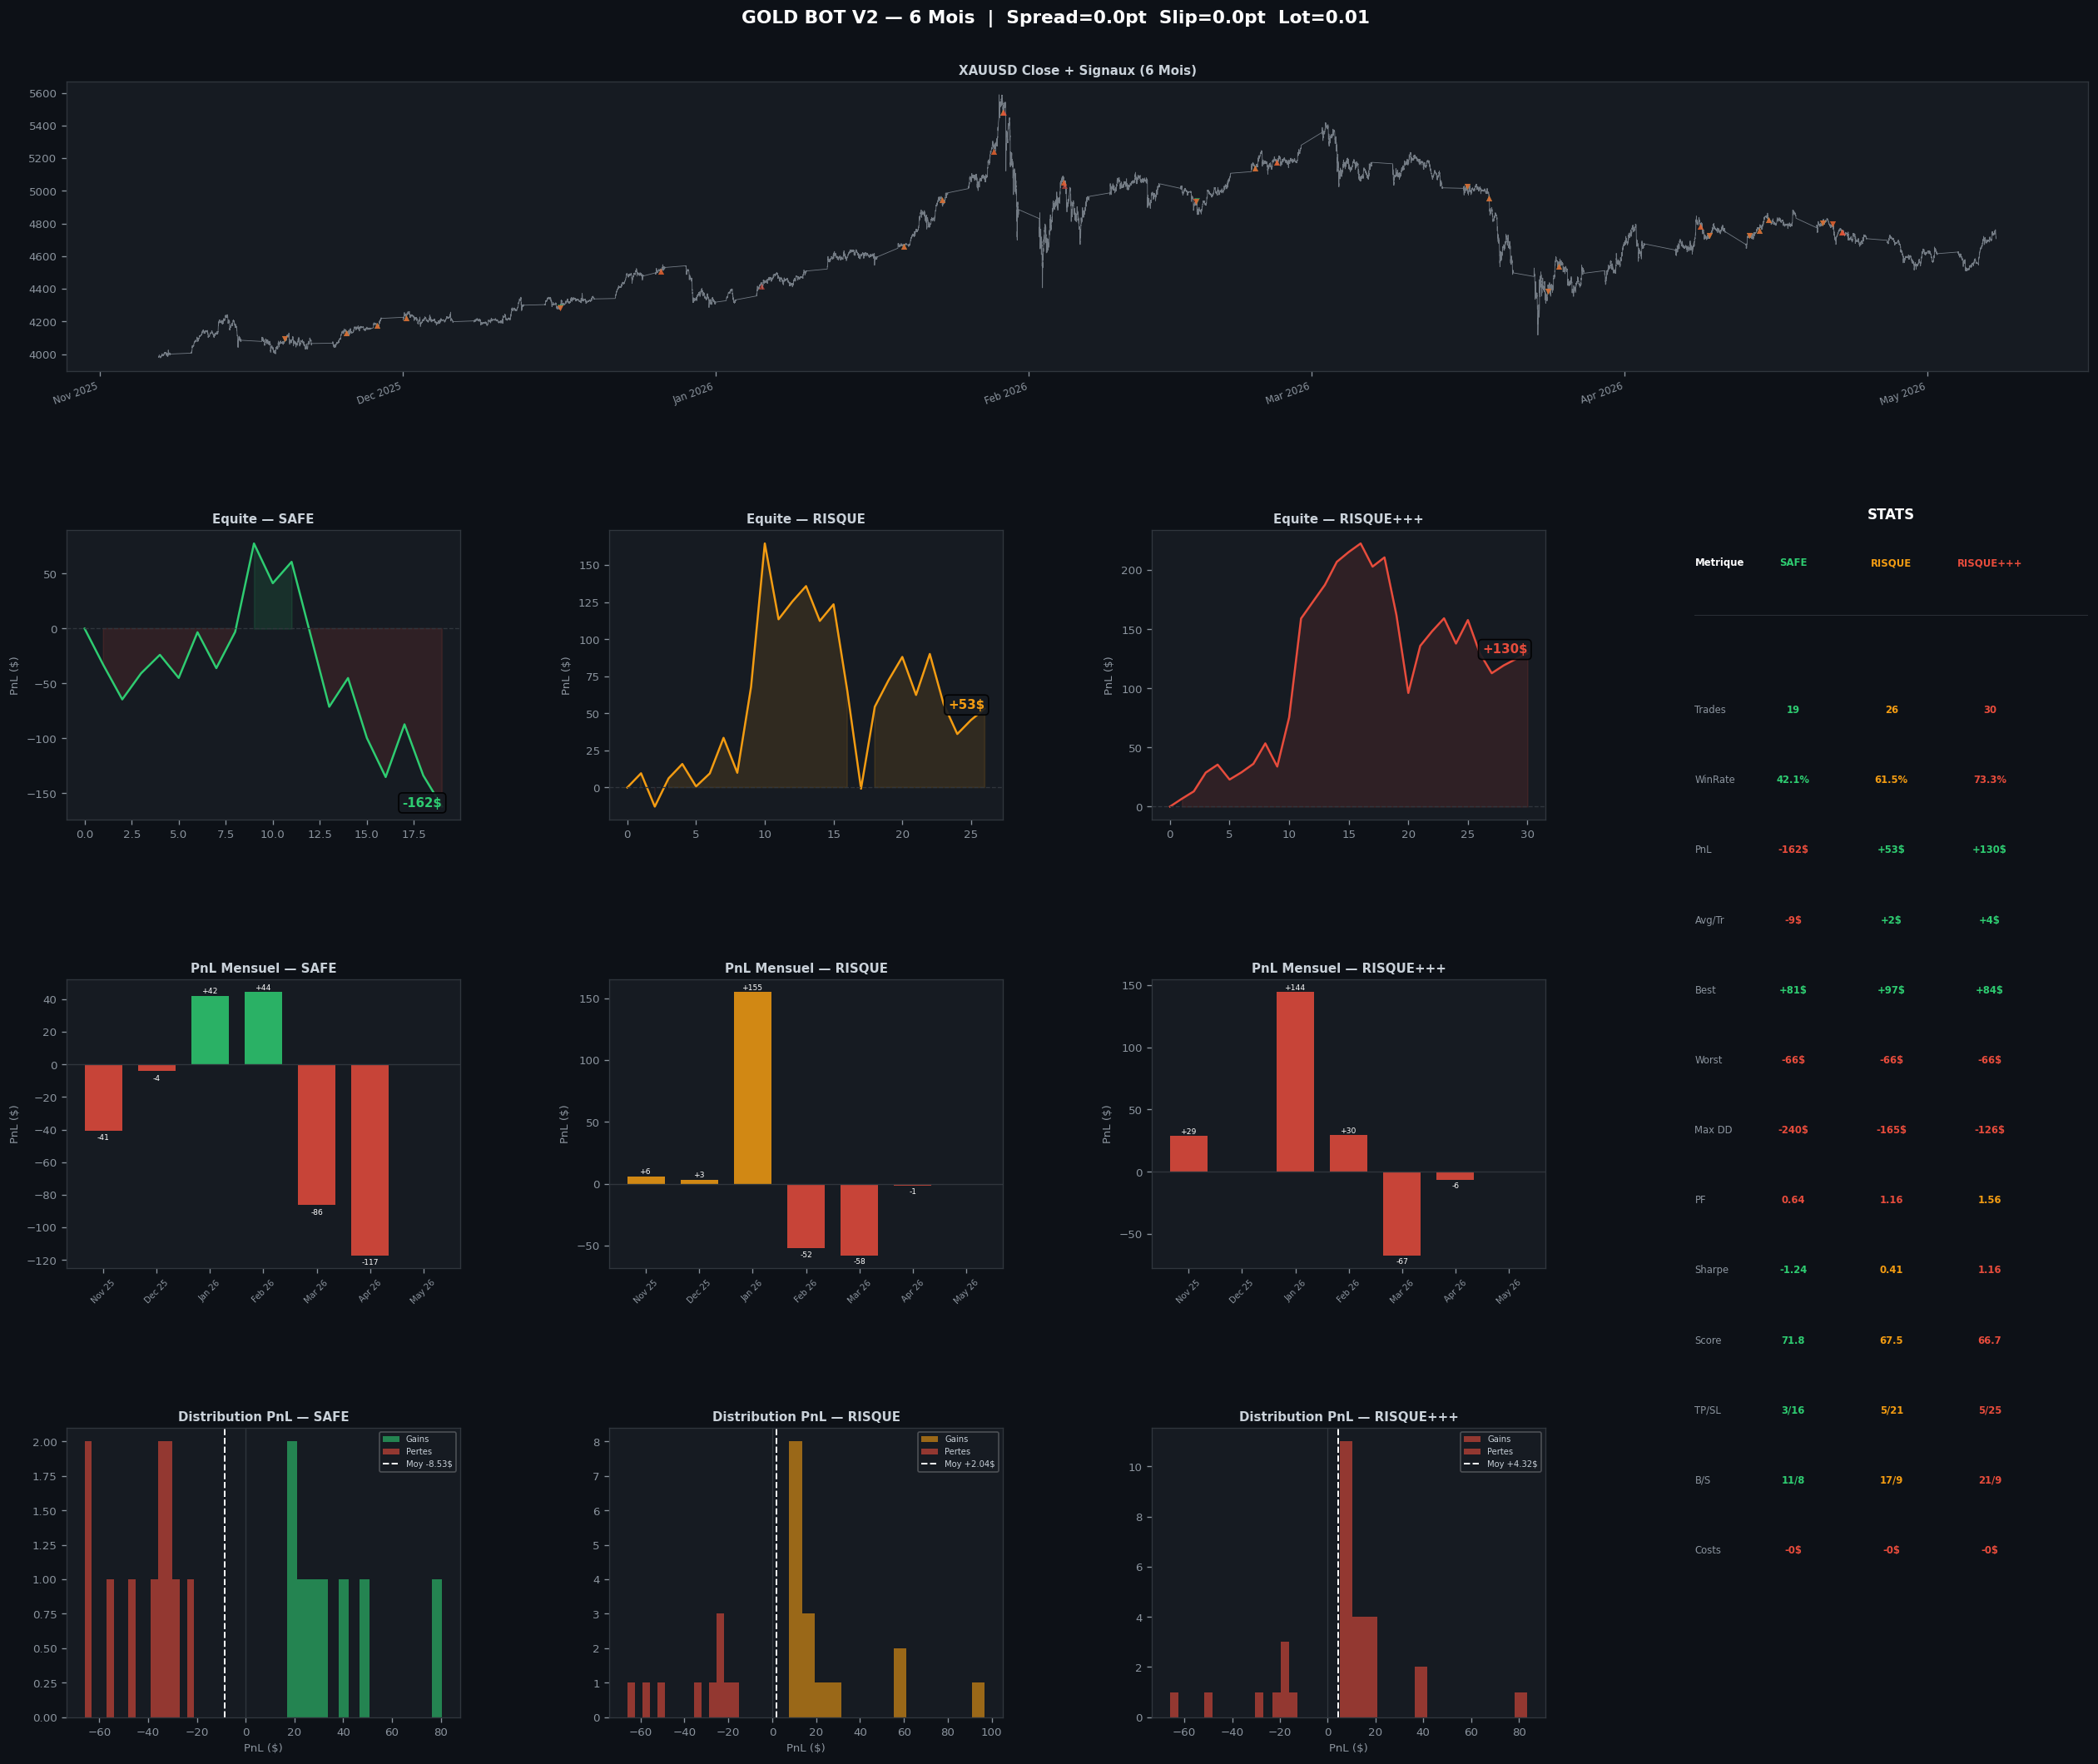

Dashboard sauvegarde: dashboard_6_Mois.png

  Dashboard: 1 An


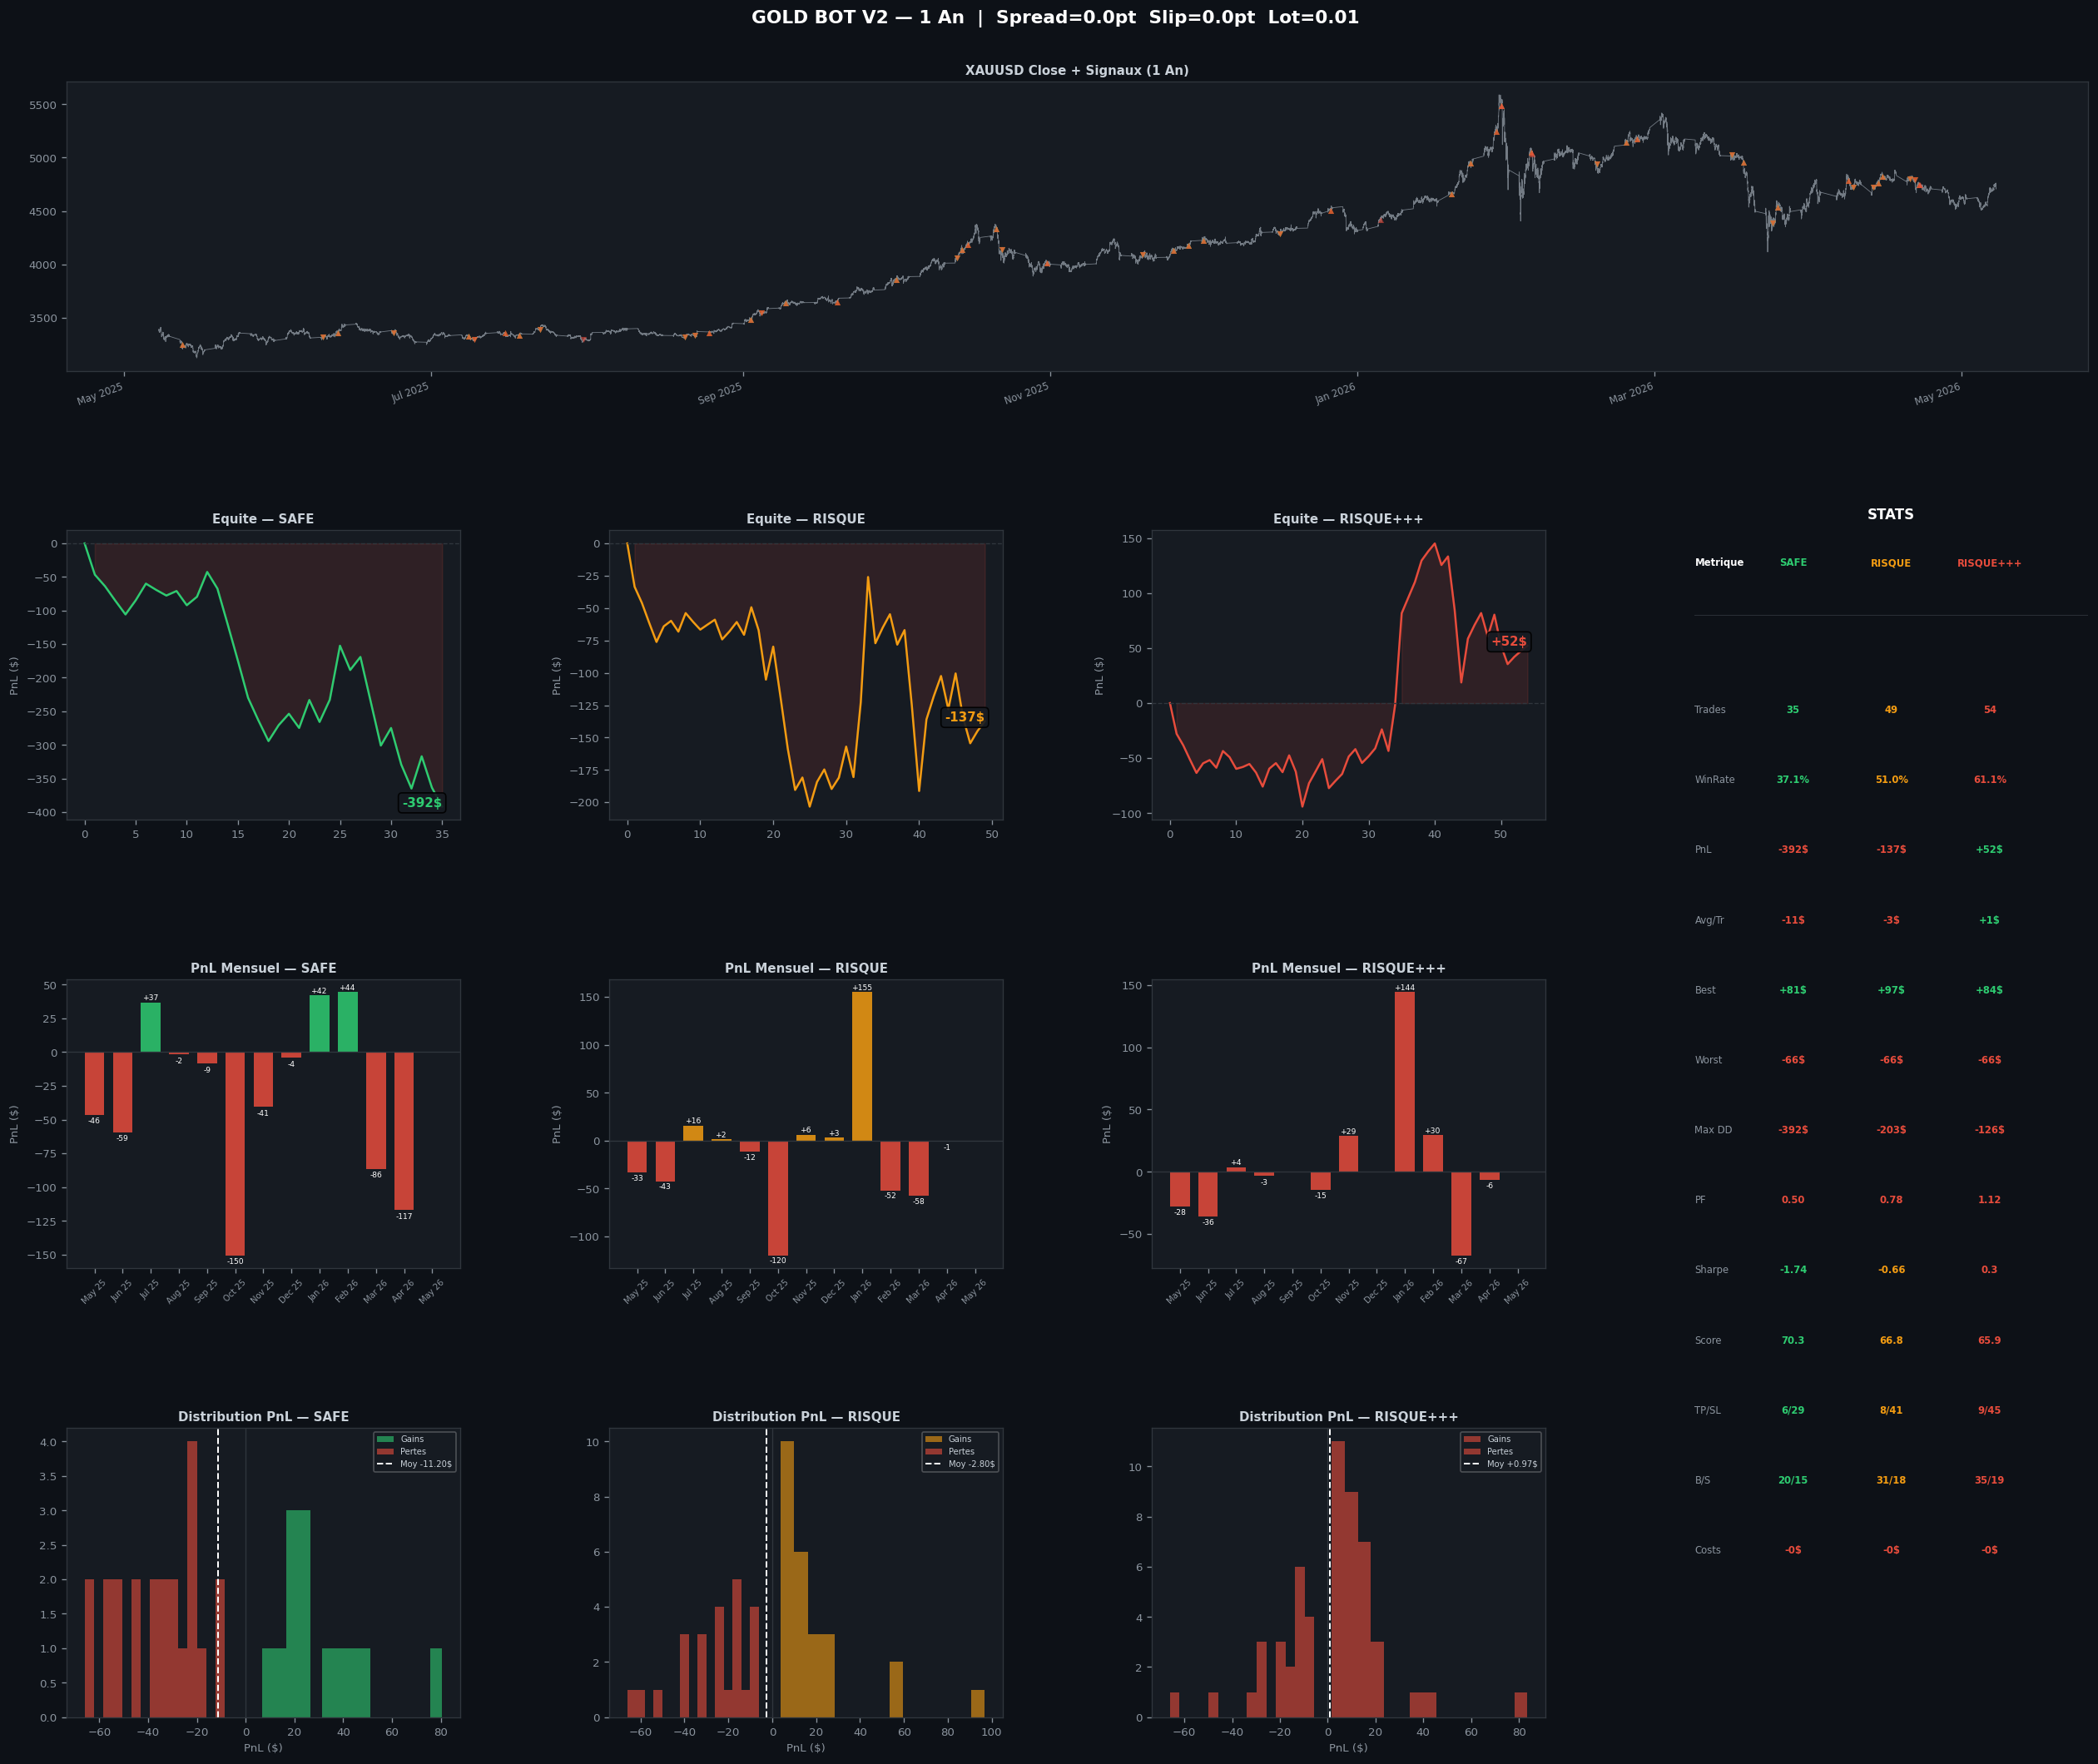

Dashboard sauvegarde: dashboard_1_An.png

  Dashboard: 2 Ans


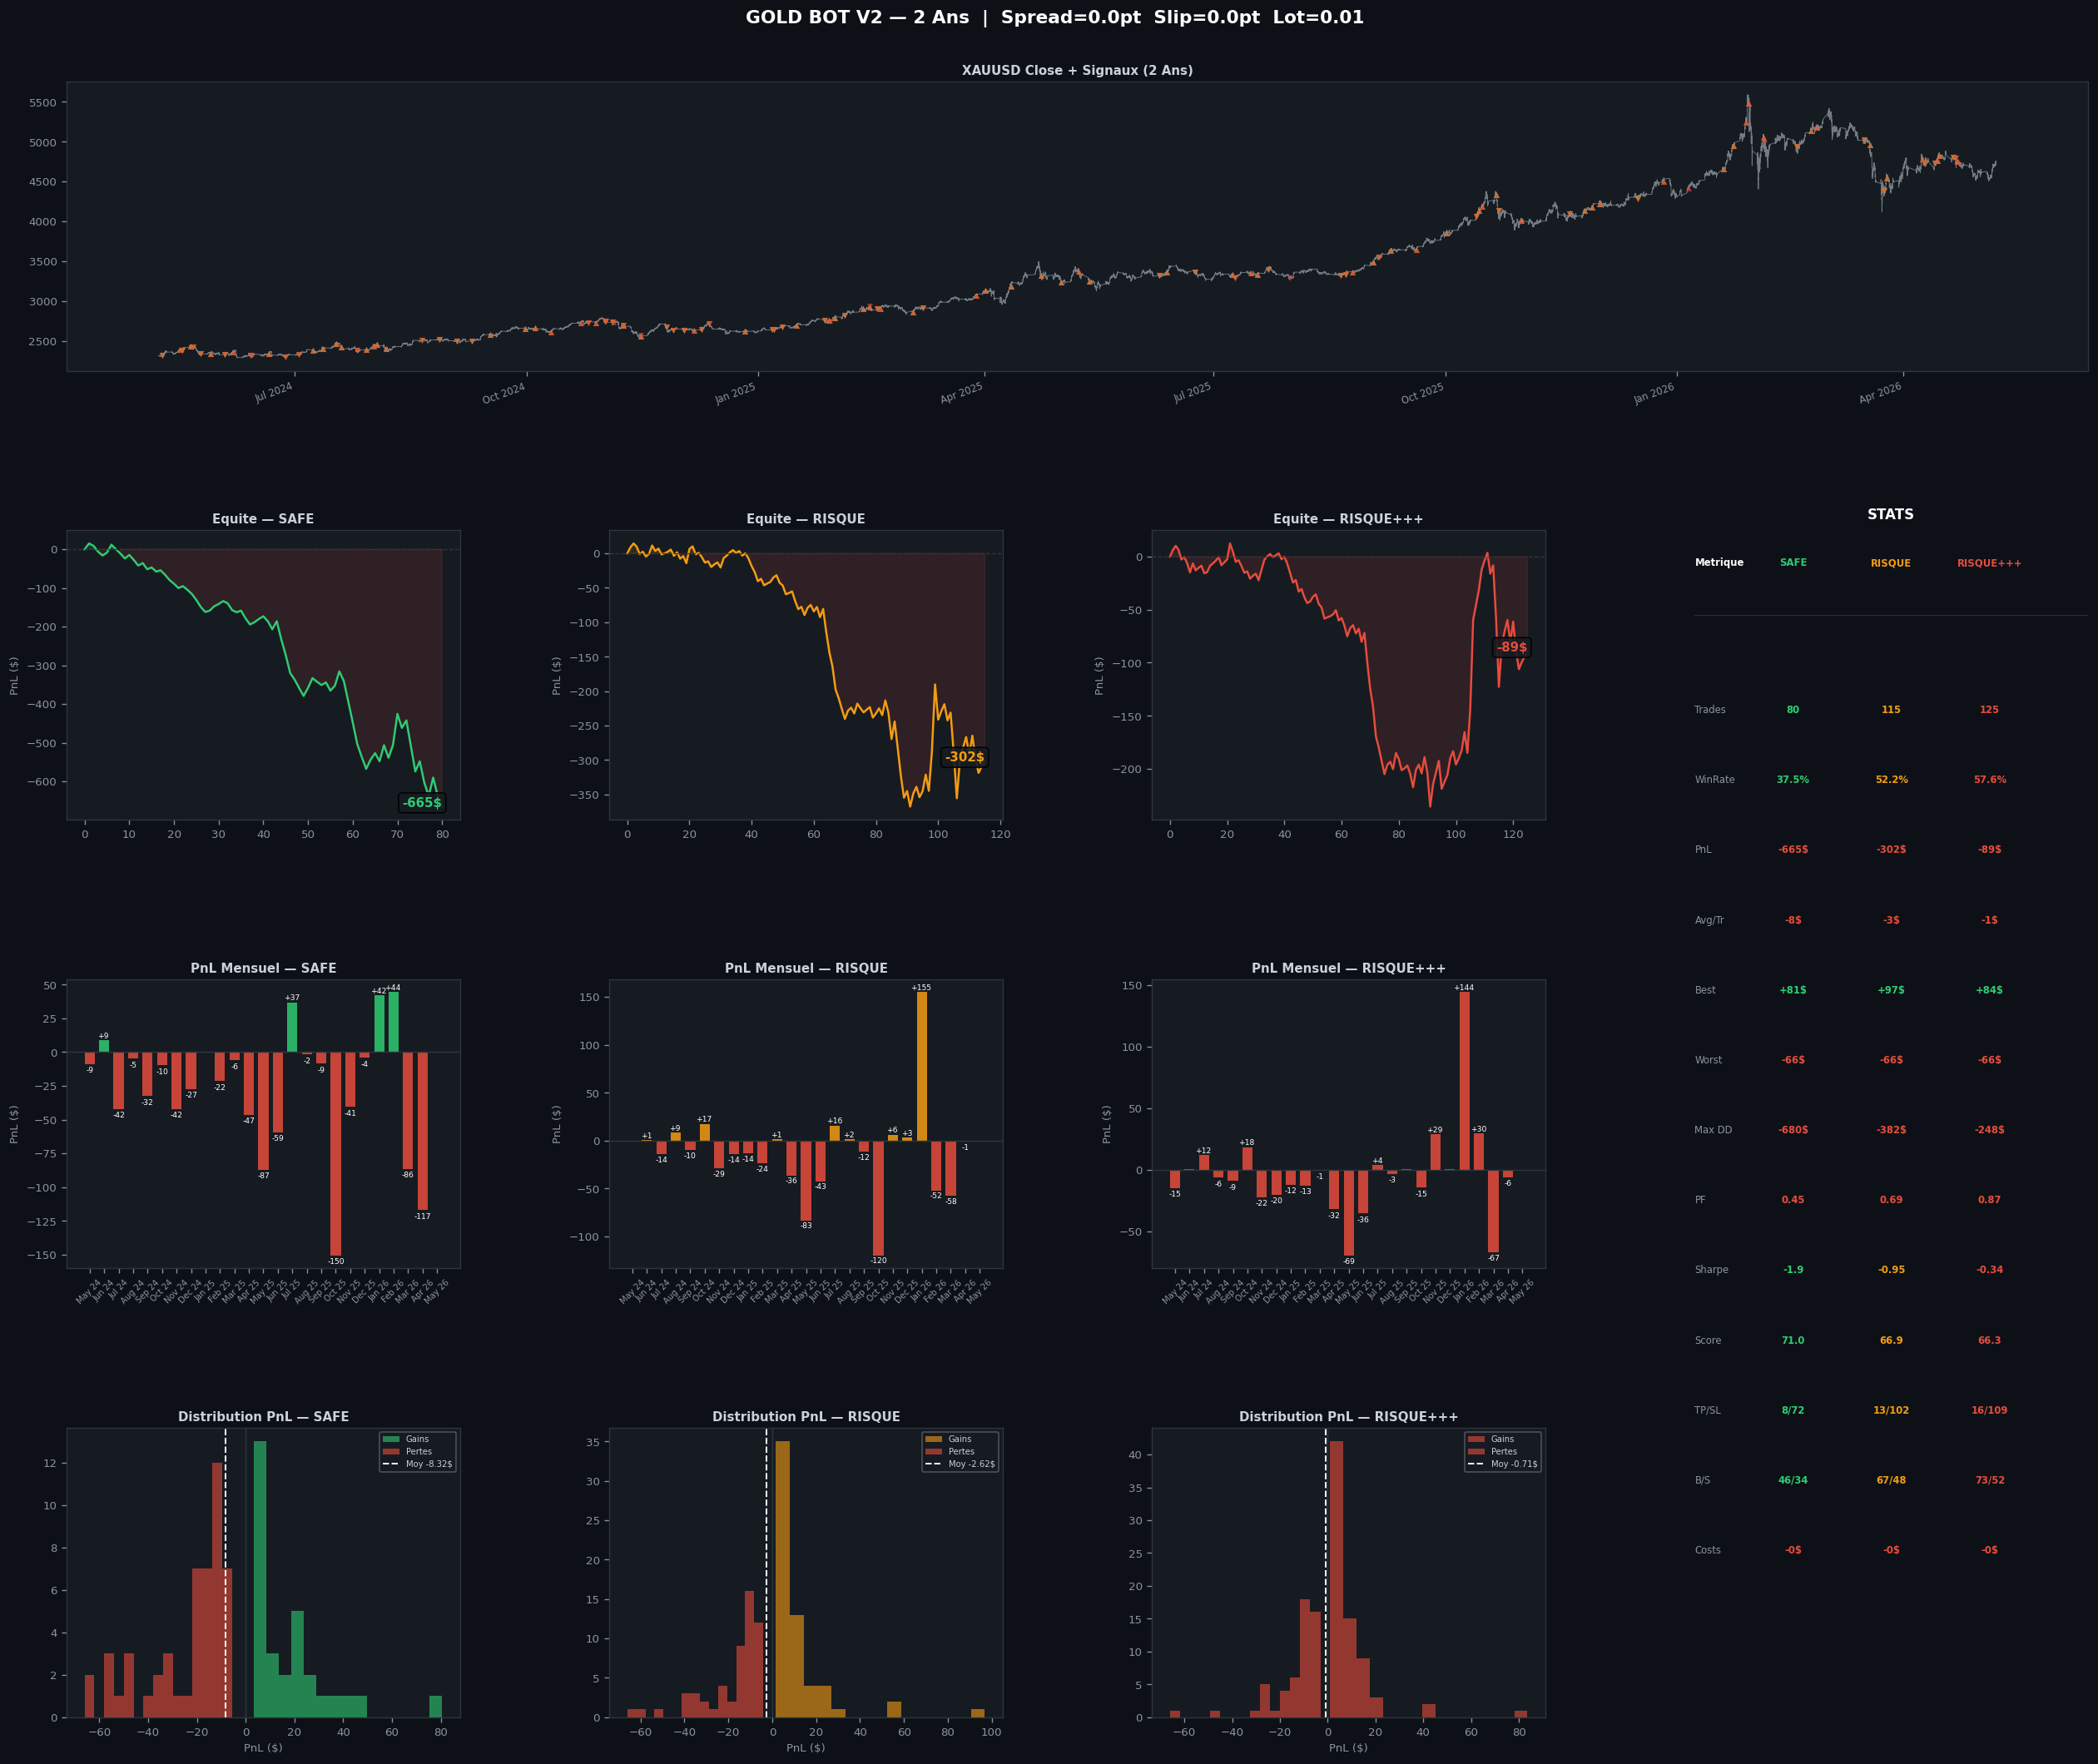

Dashboard sauvegarde: dashboard_2_Ans.png

  Dashboard: 3 Ans


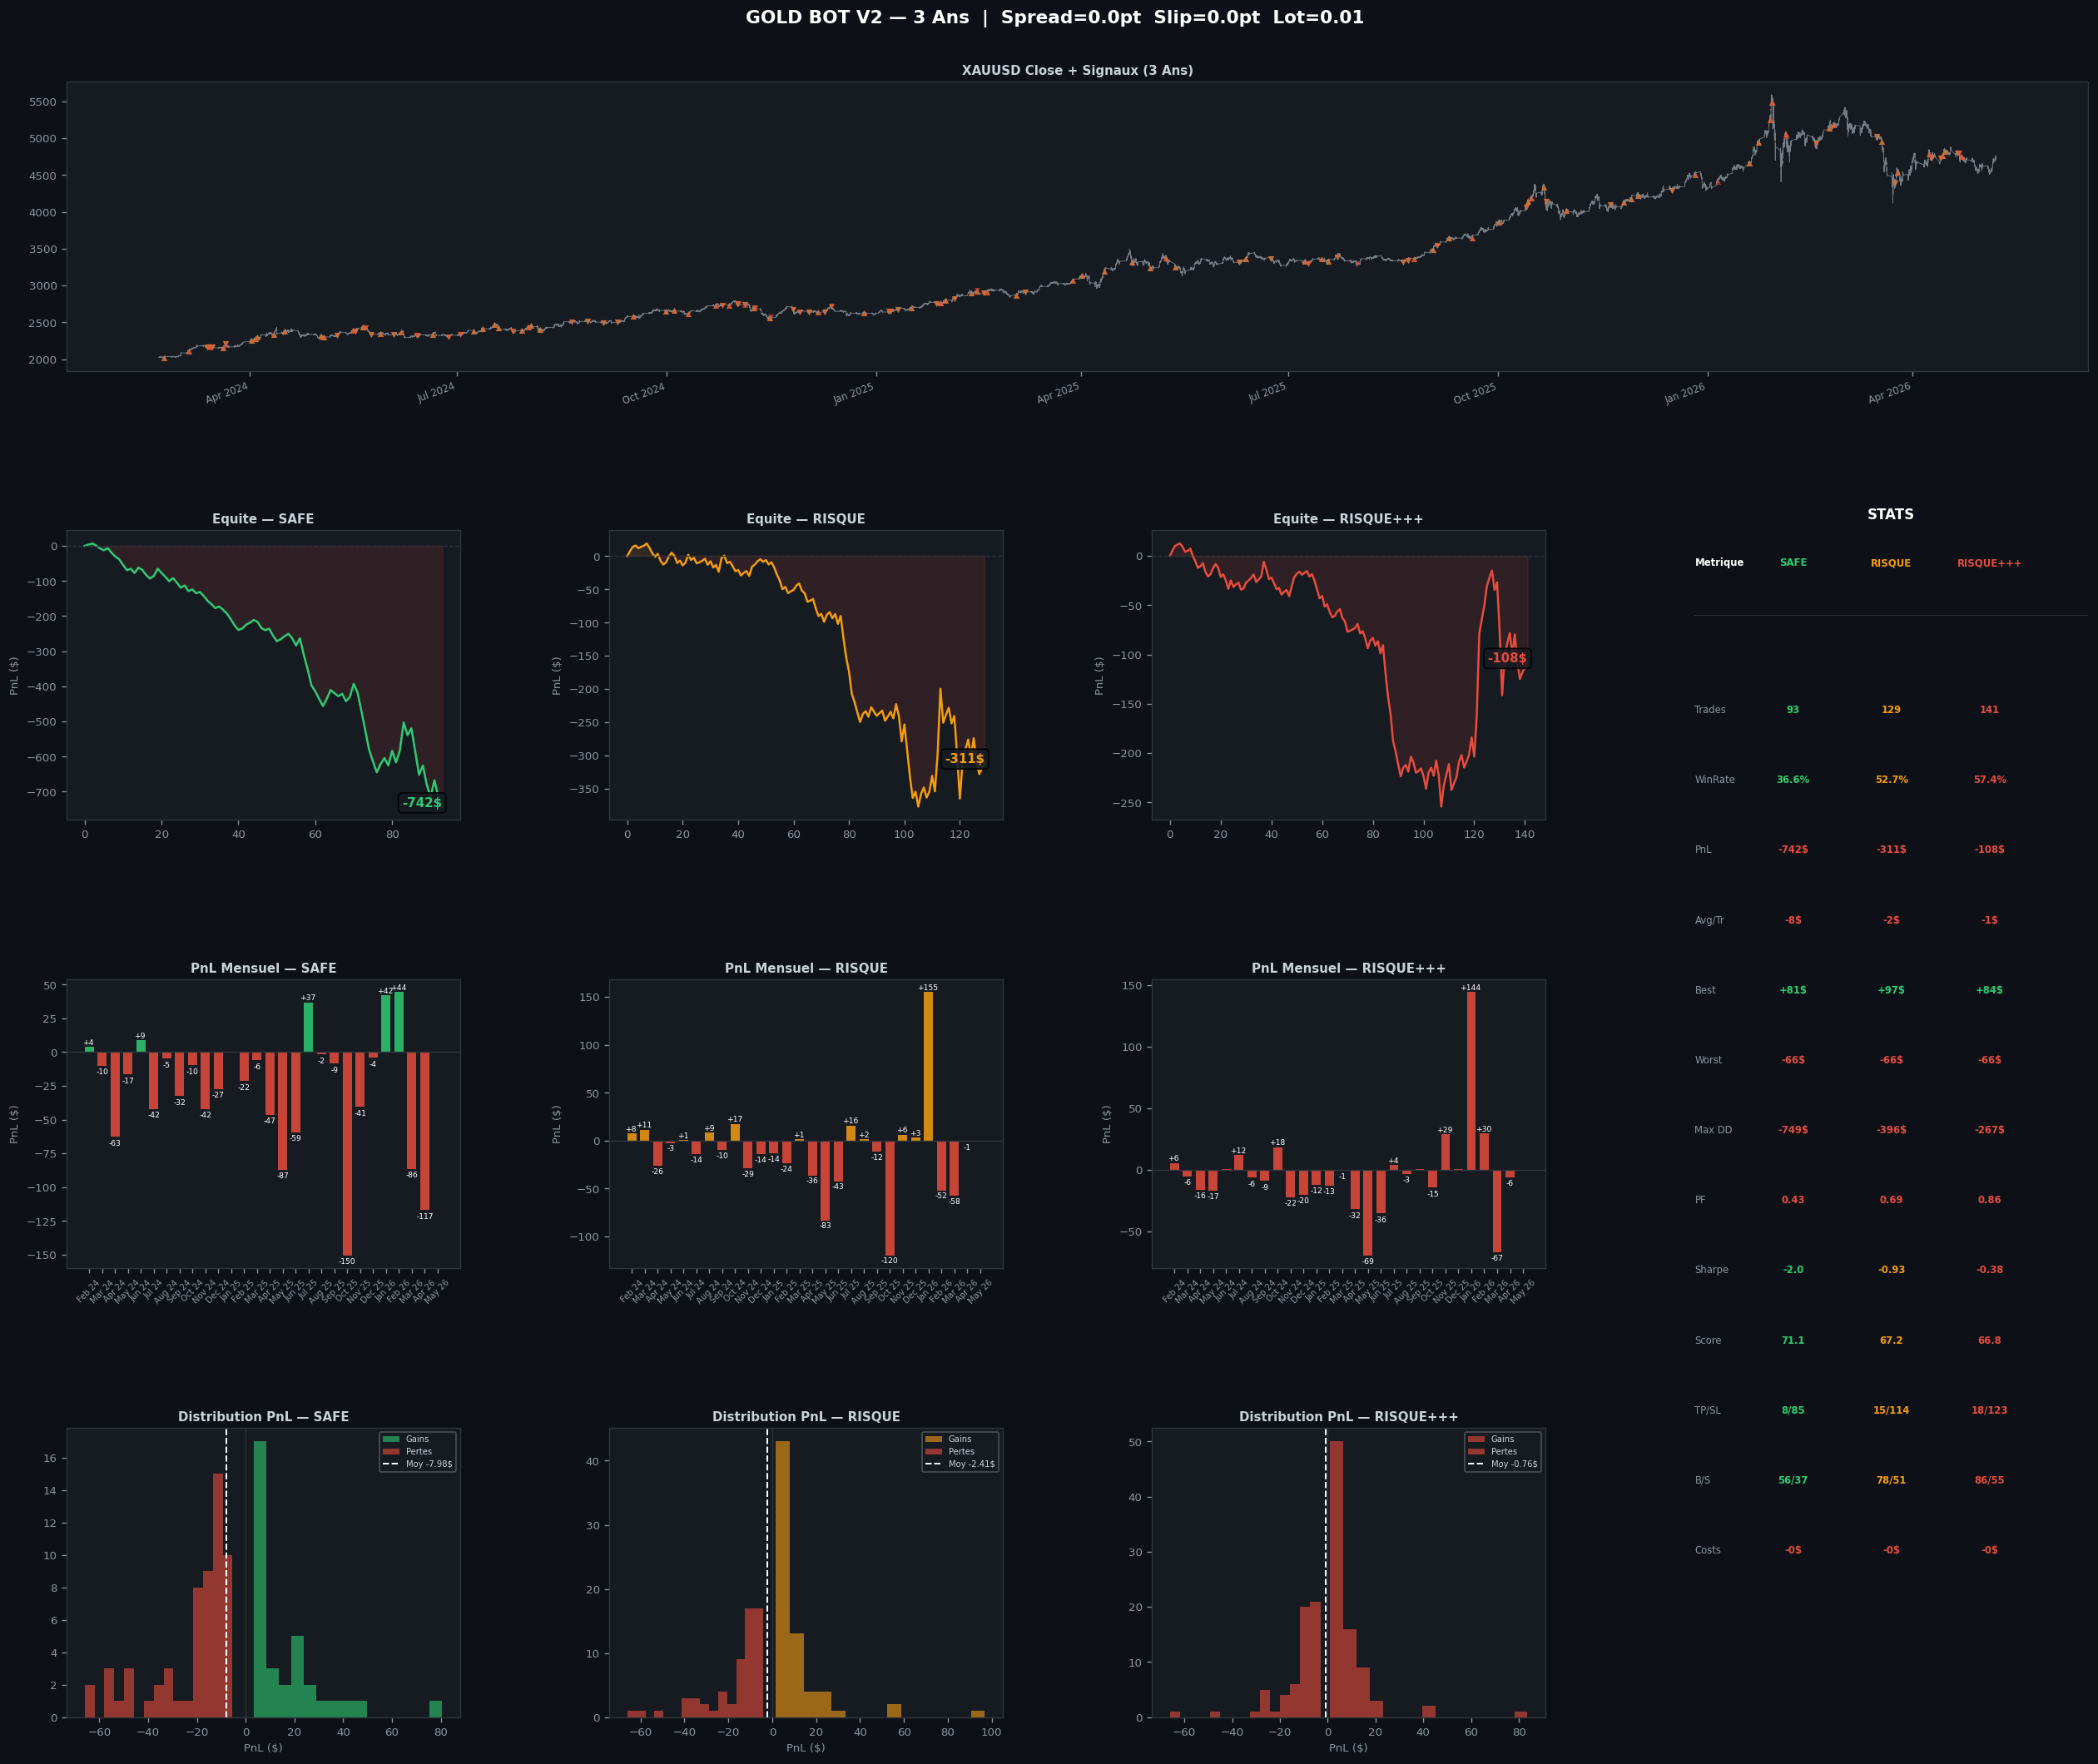

Dashboard sauvegarde: dashboard_3_Ans.png


In [8]:
BG='#0d1117'; BG2='#161b22'; BD='#30363d'; TXT='#c9d1d9'; MT='#8b949e'

def sax(ax,title=''):
    ax.set_facecolor(BG2)
    for s in ax.spines.values(): s.set_color(BD)
    ax.tick_params(colors=MT,labelsize=8)
    ax.xaxis.label.set_color(MT); ax.yaxis.label.set_color(MT)
    if title: ax.set_title(title,color=TXT,fontsize=9,fontweight='bold',pad=5)

def plot_dashboard(ds_name,df_price,mres):
    ml=list(mres.keys()); n=len(ml)
    colors=[MODES_CONFIG[m]['color'] for m in ml]
    labels=[MODES_CONFIG[m]['label'] for m in ml]
    fig=plt.figure(figsize=(22,18),facecolor=BG)
    fig.suptitle(f'GOLD BOT V2 — {ds_name}  |  Spread={SPREAD}pt  Slip={SLIPPAGE}pt  Lot={LOT_SIZE}',
                 fontsize=13,fontweight='bold',color='white',y=0.99)
    gs=gridspec.GridSpec(4,n+1,figure=fig,hspace=0.55,wspace=0.38,
                         left=0.05,right=0.97,top=0.95,bottom=0.04)

    ax_p=fig.add_subplot(gs[0,:])
    sax(ax_p,f'XAUUSD Close + Signaux ({ds_name})')
    x=pd.to_datetime(df_price['time']) if 'time' in df_price.columns else range(len(df_price))
    ax_p.plot(x,df_price['Close'],color=MT,lw=0.5,alpha=0.8)
    for m,col in zip(ml,colors):
        td=mres[m]['trades_df']
        if td.empty: continue
        bu=td[td['direction']=='BUY']; se=td[td['direction']=='SELL']
        bx=pd.to_datetime(bu['time']); sx=pd.to_datetime(se['time'])
        ax_p.scatter(bx,bu['entry_raw'],marker='^',s=18,color=col,alpha=0.6,zorder=3,linewidths=0)
        ax_p.scatter(sx,se['entry_raw'],marker='v',s=18,color=col,alpha=0.6,zorder=3,linewidths=0)
    ax_p.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
    plt.setp(ax_p.xaxis.get_majorticklabels(),rotation=20,ha='right',fontsize=7)

    for col,(mode,color,label) in enumerate(zip(ml,colors,labels)):
        res=mres[mode]; ax=fig.add_subplot(gs[1,col])
        sax(ax,f'Equite — {label}')
        eq=res['equity']; xe=range(len(eq))
        ax.plot(xe,eq,color=color,lw=1.5)
        ax.axhline(0,color=BD,lw=0.8,ls='--')
        ax.fill_between(xe,eq,0,where=[e>0 for e in eq],alpha=0.12,color=color)
        ax.fill_between(xe,eq,0,where=[e<0 for e in eq],alpha=0.12,color='#e74c3c')
        ax.set_ylabel('PnL ($)',fontsize=8)
        f=eq[-1]
        ax.annotate(f'{f:+.0f}$',xy=(len(eq)-1,f),color=color,fontsize=9,
                    fontweight='bold',ha='right',
                    bbox=dict(boxstyle='round,pad=0.3',facecolor=BG2,alpha=0.9))

    for col,(mode,color,label) in enumerate(zip(ml,colors,labels)):
        res=mres[mode]; ax=fig.add_subplot(gs[2,col])
        sax(ax,f'PnL Mensuel — {label}')
        if not res['daily_pnl']: continue
        d=pd.Series(res['daily_pnl'])
        d.index=pd.to_datetime(list(res['daily_pnl'].keys()))
        mo=d.resample('ME').sum()
        bc=[color if v>=0 else '#e74c3c' for v in mo.values]
        bars=ax.bar(range(len(mo)),mo.values,color=bc,width=0.7,alpha=0.85)
        ax.axhline(0,color=BD,lw=0.8)
        ax.set_xticks(range(len(mo)))
        ax.set_xticklabels([d.strftime('%b %y') for d in mo.index],rotation=45,fontsize=6)
        ax.set_ylabel('PnL ($)',fontsize=8)
        for bar,v in zip(bars,mo.values):
            if abs(v)>0.5:
                ax.text(bar.get_x()+bar.get_width()/2,
                        bar.get_height()+(0.5 if v>=0 else -2),
                        f'{v:+.0f}',ha='center',va='bottom' if v>=0 else 'top',
                        fontsize=5.5,color='white')

    for col,(mode,color,label) in enumerate(zip(ml,colors,labels)):
        res=mres[mode]; ax=fig.add_subplot(gs[3,col])
        sax(ax,f'Distribution PnL — {label}')
        if res['trades_df'].empty: continue
        pnls=res['trades_df']['total_pnl']
        ax.hist(pnls[pnls>0],bins=15,color=color,alpha=0.6,label='Gains')
        ax.hist(pnls[pnls<0],bins=15,color='#e74c3c',alpha=0.6,label='Pertes')
        ax.axvline(pnls.mean(),color='white',lw=1.2,ls='--',label=f'Moy {pnls.mean():+.2f}$')
        ax.axvline(0,color=BD,lw=0.8)
        ax.legend(fontsize=6,framealpha=0.3,facecolor=BG2,labelcolor=TXT)
        ax.set_xlabel('PnL ($)',fontsize=8)

    ax_t=fig.add_subplot(gs[1:,-1])
    ax_t.set_facecolor(BG2); ax_t.axis('off')
    ax_t.set_title('STATS',color='white',fontsize=10,fontweight='bold',pad=8)
    metrics=[('Trades',  lambda r: str(r['n_sequences'])),
             ('WinRate', lambda r: f"{r['winrate']}%"),
             ('PnL',     lambda r: f"{r['total_pnl']:+.0f}$"),
             ('Avg/Tr',  lambda r: f"{r['avg_pnl']:+.0f}$"),
             ('Best',    lambda r: f"{r['best']:+.0f}$"),
             ('Worst',   lambda r: f"{r['worst']:+.0f}$"),
             ('Max DD',  lambda r: f"{r['max_dd']:.0f}$"),
             ('PF',      lambda r: f"{r['profit_factor']:.2f}" if r['profit_factor']!=float('inf') else 'inf'),
             ('Sharpe',  lambda r: str(r['sharpe'])),
             ('Score',   lambda r: f"{r['avg_score']}"),
             ('TP/SL',   lambda r: f"{r['n_tp']}/{r['n_sl']}"),
             ('B/S',     lambda r: f"{r['n_buy']}/{r['n_sell']}"),
             ('Costs',   lambda r: f"-{r['total_transaction_costs']:.0f}$")]
    hdrs=['Metrique']+[MODES_CONFIG[m]['label'] for m in ml]
    rc=[MODES_CONFIG[m]['color'] for m in ml]
    y=0.97; dy=0.059
    for j,h in enumerate(hdrs):
        xp=j/len(hdrs); c='white' if j==0 else rc[j-1]
        ax_t.text(xp,y,h,color=c,fontsize=7,fontweight='bold',transform=ax_t.transAxes,
                  ha='left' if j==0 else 'center')
    y-=dy*0.7
    ax_t.axhline(y,color=BD,lw=0.5); y-=dy*0.4
    for lbl,fn in metrics:
        y-=dy
        ax_t.text(0,y,lbl,color=MT,fontsize=7,transform=ax_t.transAxes)
        for j,mode in enumerate(ml):
            val=fn(mres[mode]); xp=(j+1)/len(hdrs); c=rc[j]
            if '$' in val:
                try:
                    vv=float(val.replace('$','').replace('+','').replace('-',''))
                    if 'Costs' in lbl: c='#e74c3c'
                    elif 'DD' in lbl: c='#e74c3c' if vv>20 else '#f39c12'
                    else: c='#2ecc71' if float(val.replace('$','').replace('+',''))>0 else '#e74c3c'
                except: pass
            elif lbl=='PF':
                try:
                    vv=float(val)
                    c='#2ecc71' if vv>=1.8 else ('#f39c12' if vv>=1.4 else '#e74c3c')
                except: pass
            ax_t.text(xp,y,val,color=c,fontsize=7,transform=ax_t.transAxes,
                      ha='center',fontweight='bold')

    fn_out=f'dashboard_{ds_name.replace(" ","_")}.png'
    plt.savefig(fn_out,dpi=130,bbox_inches='tight',facecolor=BG)
    plt.show()
    print(f'Dashboard sauvegarde: {fn_out}')

for ds_name,df in LOADED.items():
    if ds_name in ALL_RESULTS:
        print(f'\n{"="*55}\n  Dashboard: {ds_name}\n{"="*55}')
        plot_dashboard(ds_name,df,ALL_RESULTS[ds_name])


## 🏆 Comparaison Multi-Dataset


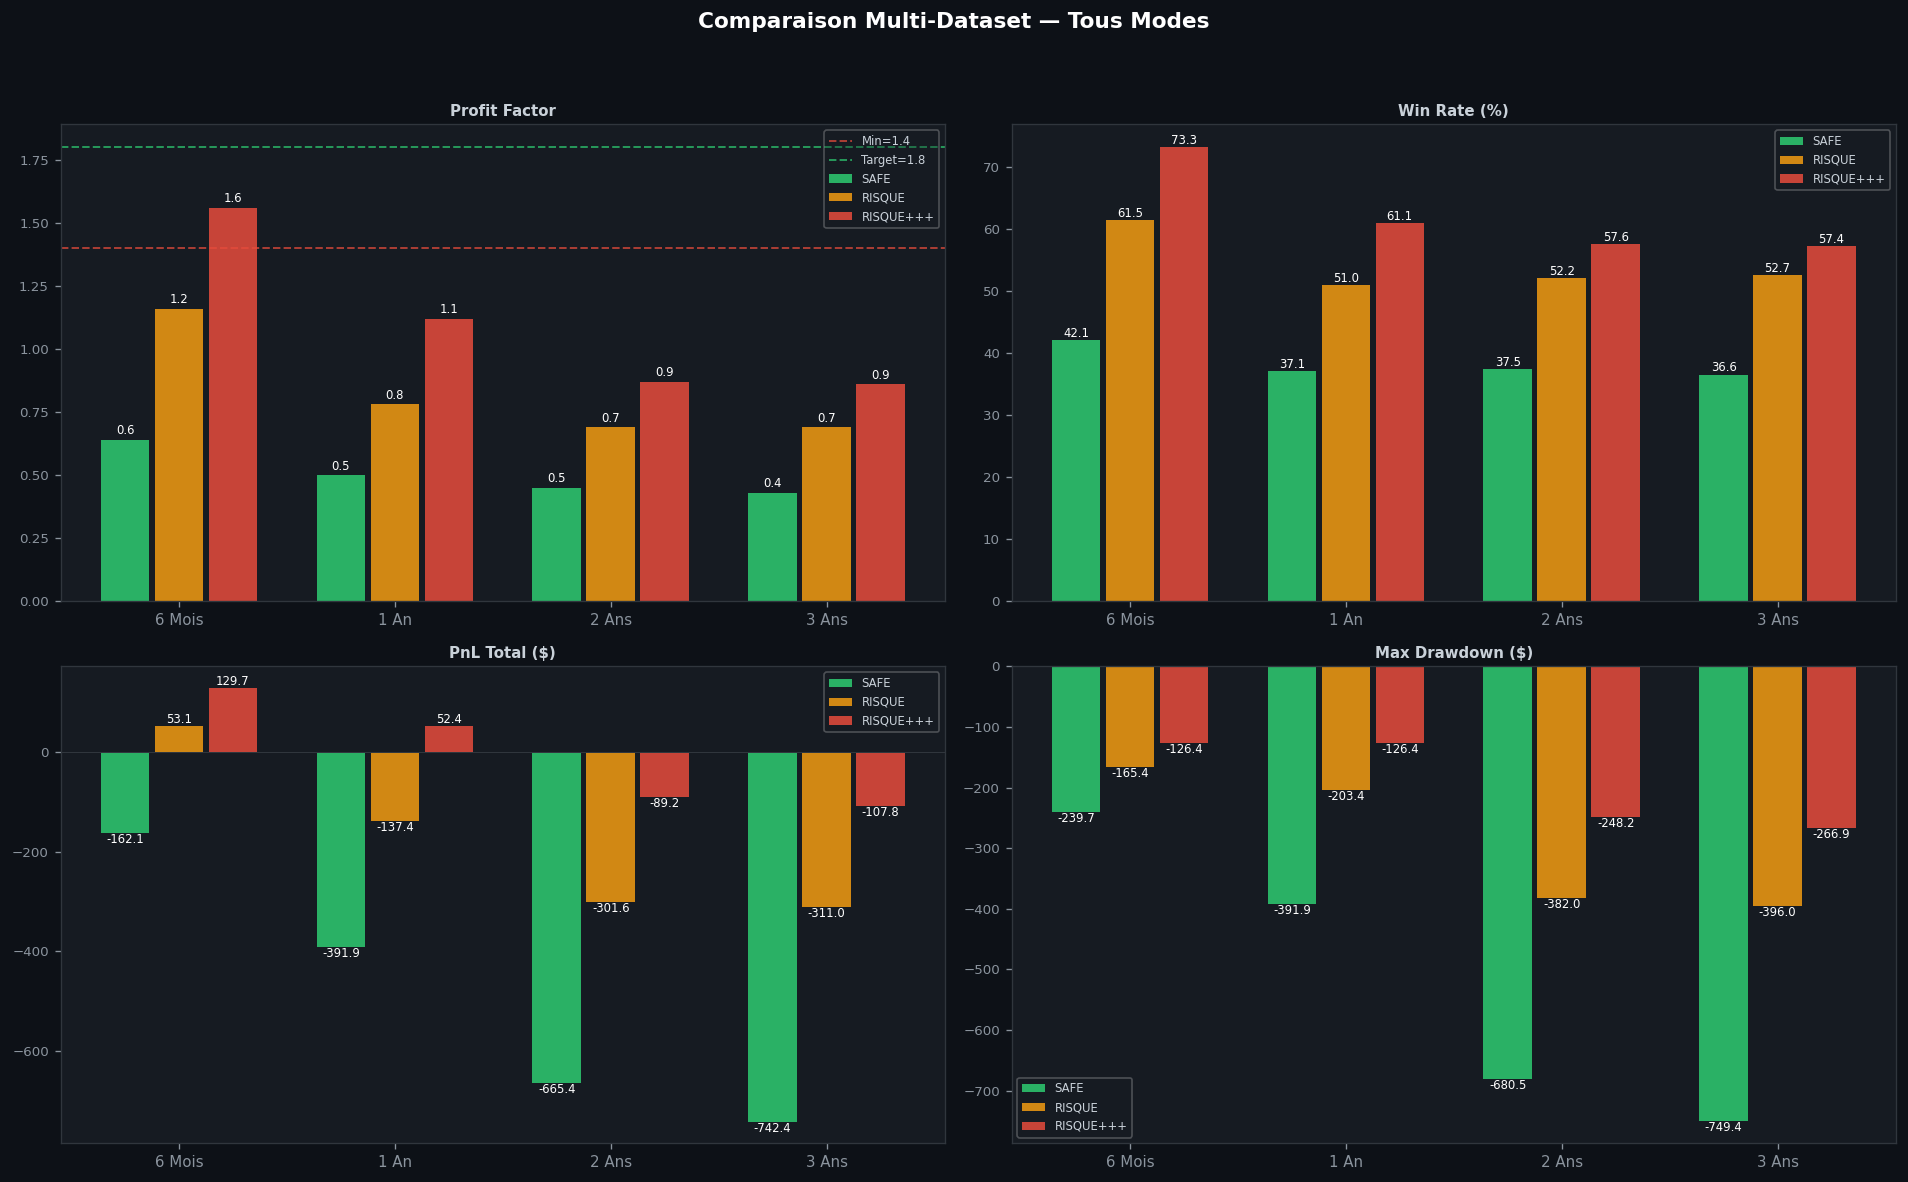

Comparaison sauvegardee: comparison_multi_dataset.png


In [9]:
if len(ALL_RESULTS)>1:
    fig,axes=plt.subplots(2,2,figsize=(16,10),facecolor=BG)
    fig.suptitle('Comparaison Multi-Dataset — Tous Modes',color='white',fontsize=13,fontweight='bold')
    metrics_chart=[
        ('profit_factor','Profit Factor',axes[0,0],[1.4,1.8]),
        ('winrate','Win Rate (%)',axes[0,1],None),
        ('total_pnl','PnL Total ($)',axes[1,0],None),
        ('max_dd','Max Drawdown ($)',axes[1,1],None),
    ]
    ds_names=list(ALL_RESULTS.keys())
    xn=np.arange(len(ds_names)); w=0.25
    for (metric,title,ax,thr) in metrics_chart:
        sax(ax,title)
        for i,mode in enumerate(MODES):
            vals=[ALL_RESULTS[ds][mode][metric] if ALL_RESULTS[ds][mode][metric]!=float('inf') else 10
                  for ds in ds_names]
            bars=ax.bar(xn+i*w-w,vals,w*0.9,label=MODES_CONFIG[mode]['label'],
                        color=MODES_CONFIG[mode]['color'],alpha=0.85)
            for bar,v in zip(bars,vals):
                ax.text(bar.get_x()+bar.get_width()/2,
                        bar.get_height()+(0.01 if v>=0 else -0.05),
                        f'{v:.1f}',ha='center',va='bottom' if v>=0 else 'top',
                        fontsize=7,color='white')
        if thr:
            for t,lbl,col in zip(thr,['Min','Target'],['#e74c3c','#2ecc71']):
                ax.axhline(t,color=col,lw=1.2,ls='--',alpha=0.7,label=f'{lbl}={t}')
        ax.axhline(0,color=BD,lw=0.6)
        ax.set_xticks(xn); ax.set_xticklabels(ds_names,fontsize=9)
        ax.legend(fontsize=7,framealpha=0.3,facecolor=BG2,labelcolor=TXT)
    plt.tight_layout(rect=[0,0,1,0.95])
    plt.savefig('comparison_multi_dataset.png',dpi=130,bbox_inches='tight',facecolor=BG)
    plt.show()
    print('Comparaison sauvegardee: comparison_multi_dataset.png')
else:
    print('Il faut au moins 2 datasets charges pour la comparaison.')


## 💾 Export Excel — Tous les Trades


In [10]:
def export_excel(filename='backtest_complet.xlsx'):
    try:
        import openpyxl
        from openpyxl.styles import PatternFill,Font,Alignment
        wb=openpyxl.Workbook(); wb.remove(wb.active)

        ws0=wb.create_sheet('RESUME GLOBAL',0)
        hdr=['Dataset','Mode','Trades','WinRate','PnL Total','PnL Moyen',
             'Meilleur','Pire','Max DD','PF','Sharpe','TP','SL','Couts']
        ws0.append(hdr)
        for cell in ws0[1]:
            cell.fill=PatternFill('solid',fgColor='1F4E79')
            cell.font=Font(color='FFFFFF',bold=True)
            cell.alignment=Alignment(horizontal='center')
        for ds,modes in ALL_RESULTS.items():
            for mode,res in modes.items():
                pf=res['profit_factor']
                ws0.append([ds,MODES_CONFIG[mode]['label'],res['n_sequences'],
                            f"{res['winrate']}%",f"{res['total_pnl']:+.2f}$",
                            f"{res['avg_pnl']:+.2f}$",f"{res['best']:+.2f}$",
                            f"{res['worst']:+.2f}$",f"{res['max_dd']:.2f}$",
                            f"{pf:.2f}" if pf!=float('inf') else 'inf',
                            res['sharpe'],res['n_tp'],res['n_sl'],
                            f"-{res['total_transaction_costs']:.2f}$"])

        cols=['time','direction','entry_raw','entry_adj','sl','tp1','tp2','tp3',
              'risk_pts','score','threshold','transaction_cost',
              't1_result','t1_pnl','t2_result','t2_pnl','t3_result','t3_pnl',
              'total_pnl','result','reasons']
        for ds,modes in ALL_RESULTS.items():
            for mode,res in modes.items():
                sht=f"{ds[:7]}_{MODES_CONFIG[mode]['label'][:6]}"
                ws=wb.create_sheet(sht[:31])
                ws.append(cols)
                for cell in ws[1]:
                    cell.fill=PatternFill('solid',fgColor='1F4E79')
                    cell.font=Font(color='FFFFFF',bold=True)
                    cell.alignment=Alignment(horizontal='center')
                if res['trades_df'].empty: ws.append(['Aucun trade']); continue
                df_t=res['trades_df']
                ec=[c for c in cols if c in df_t.columns]
                for _,row in df_t[ec].iterrows():
                    ws.append(list(row))
                    last=ws.max_row
                    pnl=row.get('total_pnl',0)
                    if 'total_pnl' in ec:
                        idx=ec.index('total_pnl')+1
                        ws.cell(last,idx).fill=PatternFill('solid',fgColor='1a5c2e' if pnl>0 else '5c1a1a')
                        ws.cell(last,idx).font=Font(color='FFFFFF',bold=True)

        wb.save(filename)
        print(f'Export OK: {filename}')
        print(f'Feuilles: RESUME GLOBAL + {sum(len(v) for v in ALL_RESULTS.values())} onglets trades')
    except ImportError:
        print('openpyxl manquant — pip install openpyxl')

export_excel()


Export OK: backtest_complet.xlsx
Feuilles: RESUME GLOBAL + 12 onglets trades


## 🎯 Recommandations Finales


In [11]:
print('\n' + '='*65)
print('  ANALYSE & RECOMMANDATIONS')
print('='*65)

for ds_name,modes in ALL_RESULTS.items():
    print(f'\nDataset: {ds_name}')
    bpf=max(modes,key=lambda m: modes[m]['profit_factor'] if modes[m]['profit_factor']!=float('inf') else 999)
    bsh=max(modes,key=lambda m: modes[m]['sharpe'])
    for mode,res in modes.items():
        pf=res['profit_factor']
        pfs=f'{pf:.2f}' if pf!=float('inf') else 'inf'
        pff='[OK]' if pf>=1.8 else ('[WARN]' if pf>=1.4 else '[FAIL]')
        ddf='[OK]' if abs(res['max_dd'])<50 else ('[WARN]' if abs(res['max_dd'])<100 else '[FAIL]')
        m=MODES_CONFIG[mode]
        print(f'   {m["label"]:12s} PF={pfs} {pff}  DD={res["max_dd"]:.0f}$ {ddf}  '
              f'Sharpe={res["sharpe"]:5.2f}  WR={res["winrate"]}%')
    print(f'   -> Meilleur PF:     {MODES_CONFIG[bpf]["label"]}')
    print(f'   -> Meilleur Sharpe: {MODES_CONFIG[bsh]["label"]}')

print('\n' + '-'*65)
print('  Criteres pour passer en LIVE :')
print('   Profit Factor > 1.8  (minimum absolu : 1.4)')
print('   Max Drawdown  < 15% du capital')
print('   Sharpe        > 1.0')
print('   Win Rate      > 45%')
print(f'  Config: Spread={SPREAD}pt | Slippage={SLIPPAGE}pt | Lot={LOT_SIZE}')
print('='*65)



  ANALYSE & RECOMMANDATIONS

Dataset: 6 Mois
   SAFE         PF=0.64 [FAIL]  DD=-240$ [FAIL]  Sharpe=-1.24  WR=42.1%
   RISQUE       PF=1.16 [FAIL]  DD=-165$ [FAIL]  Sharpe= 0.41  WR=61.5%
   RISQUE+++    PF=1.56 [WARN]  DD=-126$ [FAIL]  Sharpe= 1.16  WR=73.3%
   -> Meilleur PF:     RISQUE+++
   -> Meilleur Sharpe: RISQUE+++

Dataset: 1 An
   SAFE         PF=0.50 [FAIL]  DD=-392$ [FAIL]  Sharpe=-1.74  WR=37.1%
   RISQUE       PF=0.78 [FAIL]  DD=-203$ [FAIL]  Sharpe=-0.66  WR=51.0%
   RISQUE+++    PF=1.12 [FAIL]  DD=-126$ [FAIL]  Sharpe= 0.30  WR=61.1%
   -> Meilleur PF:     RISQUE+++
   -> Meilleur Sharpe: RISQUE+++

Dataset: 2 Ans
   SAFE         PF=0.45 [FAIL]  DD=-680$ [FAIL]  Sharpe=-1.90  WR=37.5%
   RISQUE       PF=0.69 [FAIL]  DD=-382$ [FAIL]  Sharpe=-0.95  WR=52.2%
   RISQUE+++    PF=0.87 [FAIL]  DD=-248$ [FAIL]  Sharpe=-0.34  WR=57.6%
   -> Meilleur PF:     RISQUE+++
   -> Meilleur Sharpe: RISQUE+++

Dataset: 3 Ans
   SAFE         PF=0.43 [FAIL]  DD=-749$ [FAIL]  Sharpe=-2.00